# Лабораторная работа №1


С помощью приложенного файла сгенерировать временной ряд. 
1. Отрисовать ряд. 
2. Провести классические статистические тесты. 
3. Провести разделение ряда на компоненты.
4. Отрисовать автокорреляционные функции. 
5. Выбрать статистический метод моделирования. Привести текстовое обоснование выбора. Смоделировать ряд, сделав предсказание на разумный период. Провести анализ метрик. Изобразить график модели с предсказанием с учетом возможных ошибок

Функция создания временного ряда из файла.

In [7]:
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [8]:
def generate_time_series(n_points=1000, has_trend=True, has_seasonality=True, seed=None):
    """
    Генерирует временной ряд со случайными параметрами без использования
    Pandas

    Параметры:
    ----------
    n_points : int
    Количество точек данных
    has_trend : bool
    Добавлять ли тренд
    has_seasonality : bool
    Добавлять ли сезонность
    seed : int или None
    Seed для воспроизводимости

    Возвращает:
    -----------
    tuple: (dates, values) где dates - список строк дат, values - список
    значений
    """

    if seed is not None:
        np.random.seed(seed)

    # Генерируем временные метки (ежедневные данные начиная с 2020-01-01)
    start_date = datetime(2020, 1, 1)
    dates = [(start_date + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(n_points)]

    # Базовый шум (случайная компонента)
    noise = np.random.normal(0, 5, n_points)

    # Инициализируем компоненты
    trend_component = np.zeros(n_points)
    seasonal_component = np.zeros(n_points)

    # Генерируем тренд, если требуется
    if has_trend:
        # Случайно выбираем тип тренда: линейный, квадратичный или логарифмический
        trend_type = np.random.choice(['linear', 'quadratic','logarithmic'])

    if trend_type == 'linear':
        # Линейный тренд: y = mx + b
        slope = np.random.uniform(-0.5, 0.5) # случайный наклон
        intercept = np.random.uniform(50, 100) # случайное начальное значение
        trend_component = slope * np.arange(n_points) + intercept

    elif trend_type == 'quadratic':
        # Квадратичный тренд: y = ax^2 + bx + c
        a = np.random.uniform(-0.001, 0.001)
        b = np.random.uniform(-0.1, 0.1)
        c = np.random.uniform(50, 100)
        x = np.arange(n_points)
        trend_component = a * x**2 + b * x + c

    else: # logarithmic
        # Логарифмический тренд: y = a*log(x+1) + b
        a = np.random.uniform(10, 30)
        b = np.random.uniform(50, 100)
        trend_component = a * np.log(np.arange(n_points) + 1) + b

    # Генерируем сезонность, если требуется
    if has_seasonality:
        # Случайное количество сезонных компонент (1-3)
        n_seasons = np.random.randint(1, 4)

        for _ in range(n_seasons):
            # Случайные параметры для каждой сезонной компоненты
            amplitude = np.random.uniform(10, 30) # амплитуда
            period = np.random.uniform(30, 365) # период в днях
            phase = np.random.uniform(0, 2*np.pi) # фаза

            # Создаем сезонную компоненту (синусоида)
            seasonal_component += amplitude * np.sin(2*np.pi*np.arange(n_points)/period + phase)

    # Комбинируем все компоненты
    values = noise + trend_component + seasonal_component

    return dates, values


1. Отрисовка.

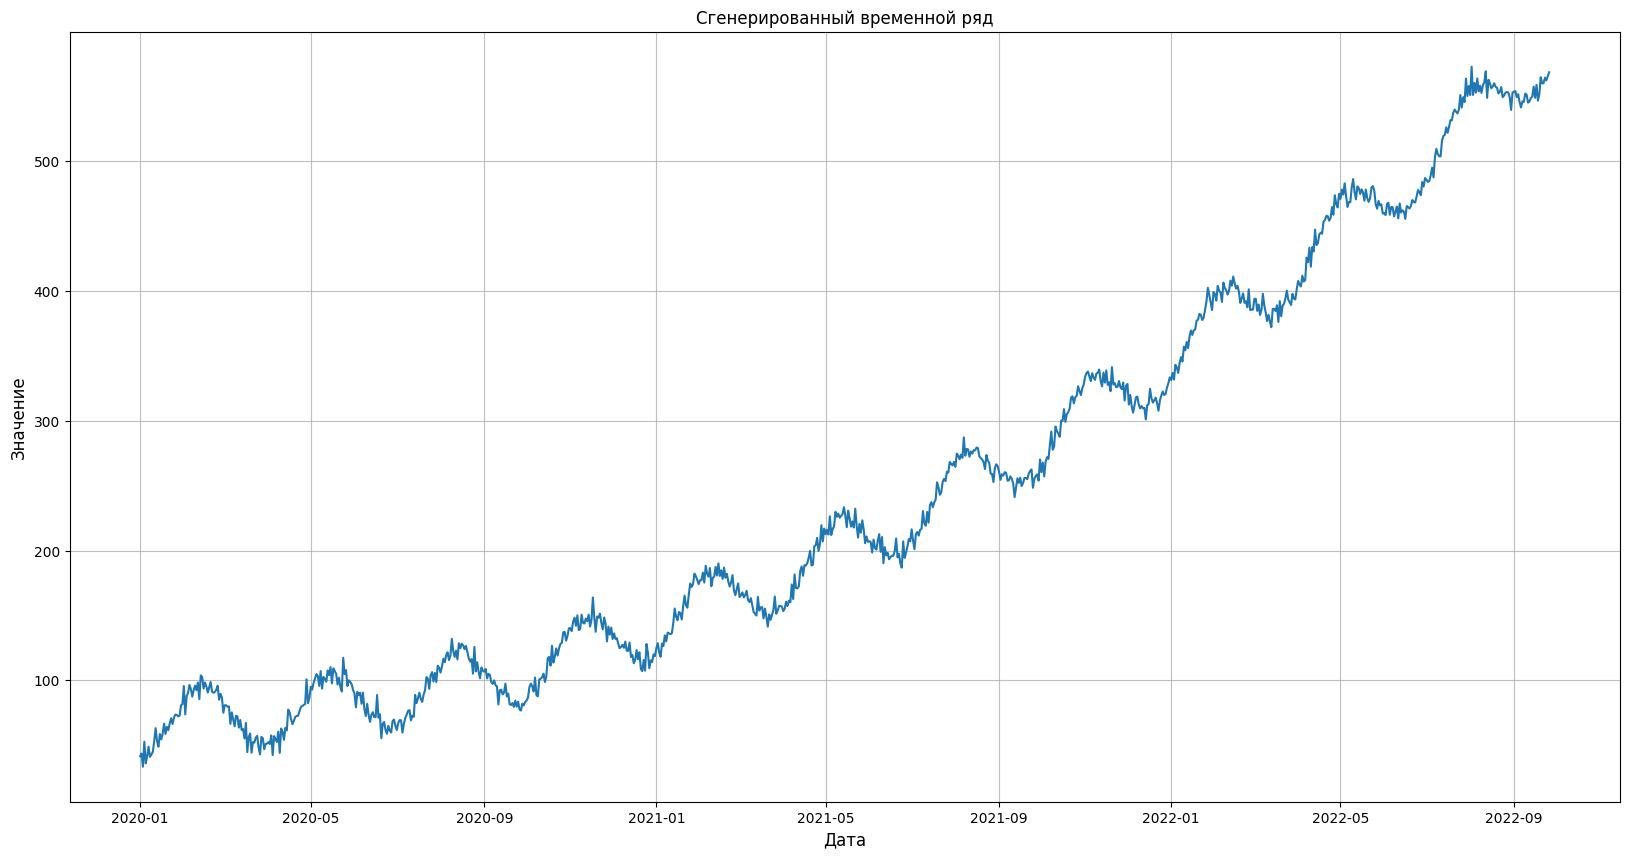

In [9]:
dates, values = generate_time_series(n_points=1000, has_trend=True, has_seasonality=True, seed=2)
date_objects = [datetime.strptime(date_str, '%Y-%m-%d') for date_str in dates]

plt.figure(figsize=(20,10))
plt.plot(date_objects, values, linewidth=1.5)
plt.title('Сгенерированный временной ряд')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.8)

2. Статистические тесты.

In [10]:
def test_stat(values):
    # Тест Дики-Фуллера на стационарность (ADF)
    print('Тест Дики-Фуллера на стационарность (ADF)')
    adf_result = adfuller(values)
    print(f'Статистика: {adf_result[0]:.6f} \nP-значение: {adf_result[1]:.6f} \nКритические значения: ')
    for key, value in adf_result[4].items():
        print(f"     {key}: {value:.6f}")
        
    # Тест Квятковского-Филлипса-Шмидта-Шина (KPSS)
    print('\nТест Квятковского-Филлипса-Шмидта-Шина (KPSS)')
    kpss_result = kpss(values) 
    print(f'Статистика: {kpss_result[0]:.6f} \nP-значение: {kpss_result[1]:.6f} \nКритические значения: ')
    for key, value in kpss_result[3].items():
        print(f"     {key}: {value:.6f}")

test_stat(values)

Тест Дики-Фуллера на стационарность (ADF)
Статистика: 0.321616 
P-значение: 0.978315 
Критические значения: 
     1%: -3.437047
     5%: -2.864497
     10%: -2.568344

Тест Квятковского-Филлипса-Шмидта-Шина (KPSS)
Статистика: 4.828714 
P-значение: 0.010000 
Критические значения: 
     10%: 0.347000
     5%: 0.463000
     2.5%: 0.574000
     1%: 0.739000


**Тест Дики-Фуллера (ADF):**
* $H_0$ (нулевая гипотеза): Временной ряд имеет единичный корень (нестационарен)
* $H_1$ (альтернативная гипотеза): Ряд стационарен

$p>0.05 \implies$ не отвергаем $H_0$ 

**Тест Квятковского-Филлипса-Шмидта-Шина (KPSS):**
* $H_0$ (нулевая гипотеза): Временной ряд стационарен вокруг детерминированного тренда
* $H_1$ (альтернативная гипотеза): Ряд нестационарен (имеет единичный корень)

$p < 0.05 \implies$ отвергаем  $H_0$ 

Из тестов следует что временной ряд **нестационарен**.

3. Разделение ряда на компоненты.

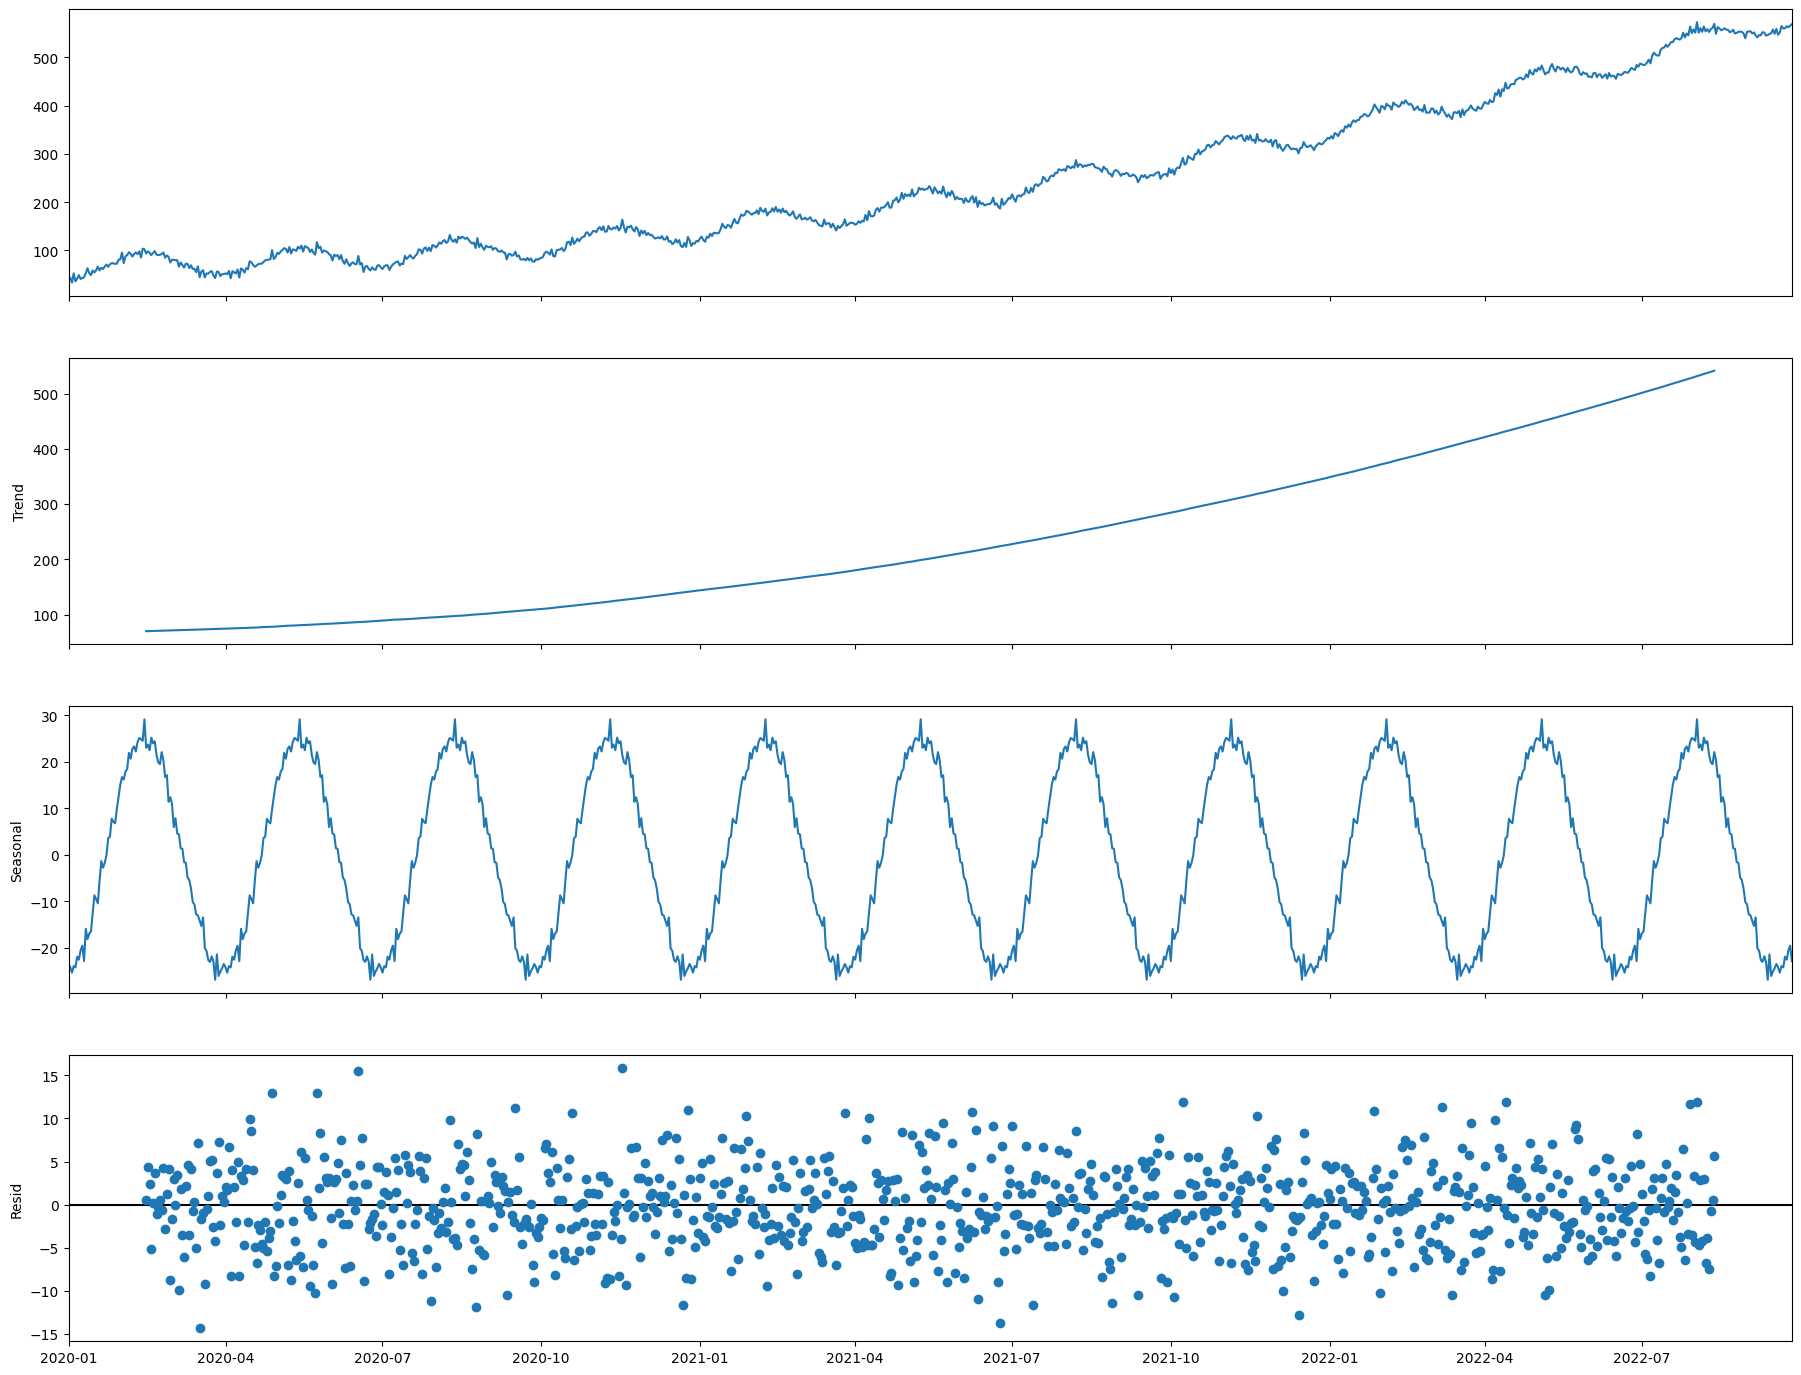

In [11]:
pd_values = pd.Series(values, index=date_objects)
decomposition = seasonal_decompose(pd_values, model='additive', period=90)
decomposition.plot().set_size_inches(20, 15)

4. Отрисовака автокорреляционных функций. 

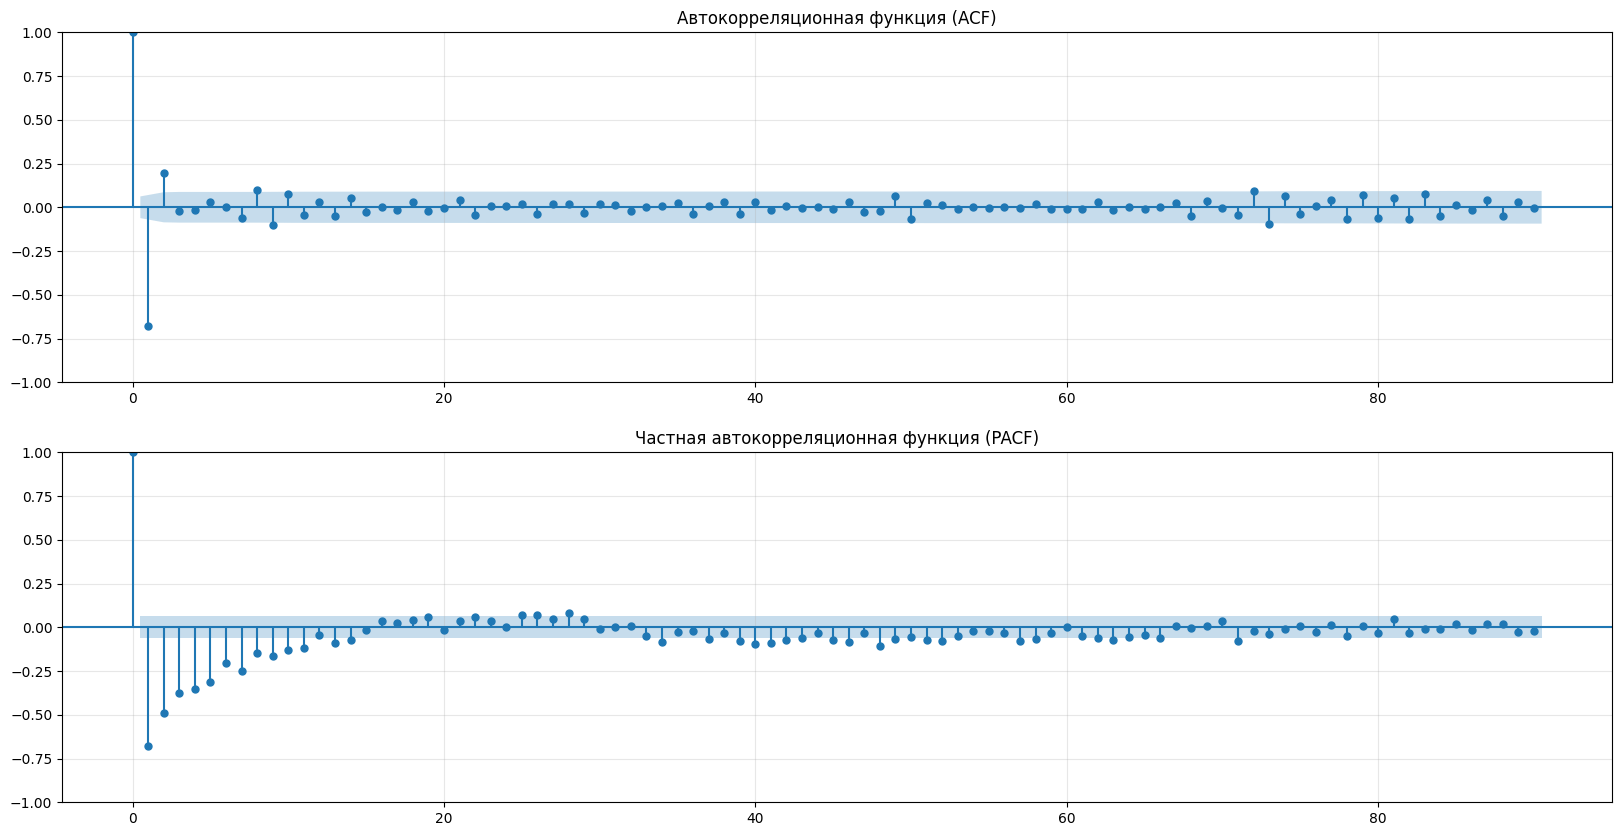

In [12]:
values_diff = np.diff(np.diff(values))
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# ACF
plot_acf(values_diff, lags=90, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(values_diff, lags=90, ax=axes[1])
axes[1].set_title('Частная автокорреляционная функция (PACF)')
axes[1].grid(True, alpha=0.3)

5. Статистический метод моделирования. <br>
Для предсказания использую модель **SARIMA** т.к. :
    1. Она учитывает сезонность (из декомпозиции видна выраженная сезонность)
    2. Работает с нестационарными временными рядами (выяснили из тестов ADF и KPSS) 
    3. Учитывает автокорреляцию (AR) и скользящее среднее (MA)

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  800
Model:             SARIMAX(9, 2, 1)x(0, 1, [], 90)   Log Likelihood               -2436.619
Date:                             Fri, 19 Dec 2025   AIC                           4895.239
Time:                                     14:25:57   BIC                           4945.426
Sample:                                 01-01-2020   HQIC                          4914.629
                                      - 03-10-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8883      0.041    -21.833      0.000      -0.968      -0.809
ar.L2         -0.7427      

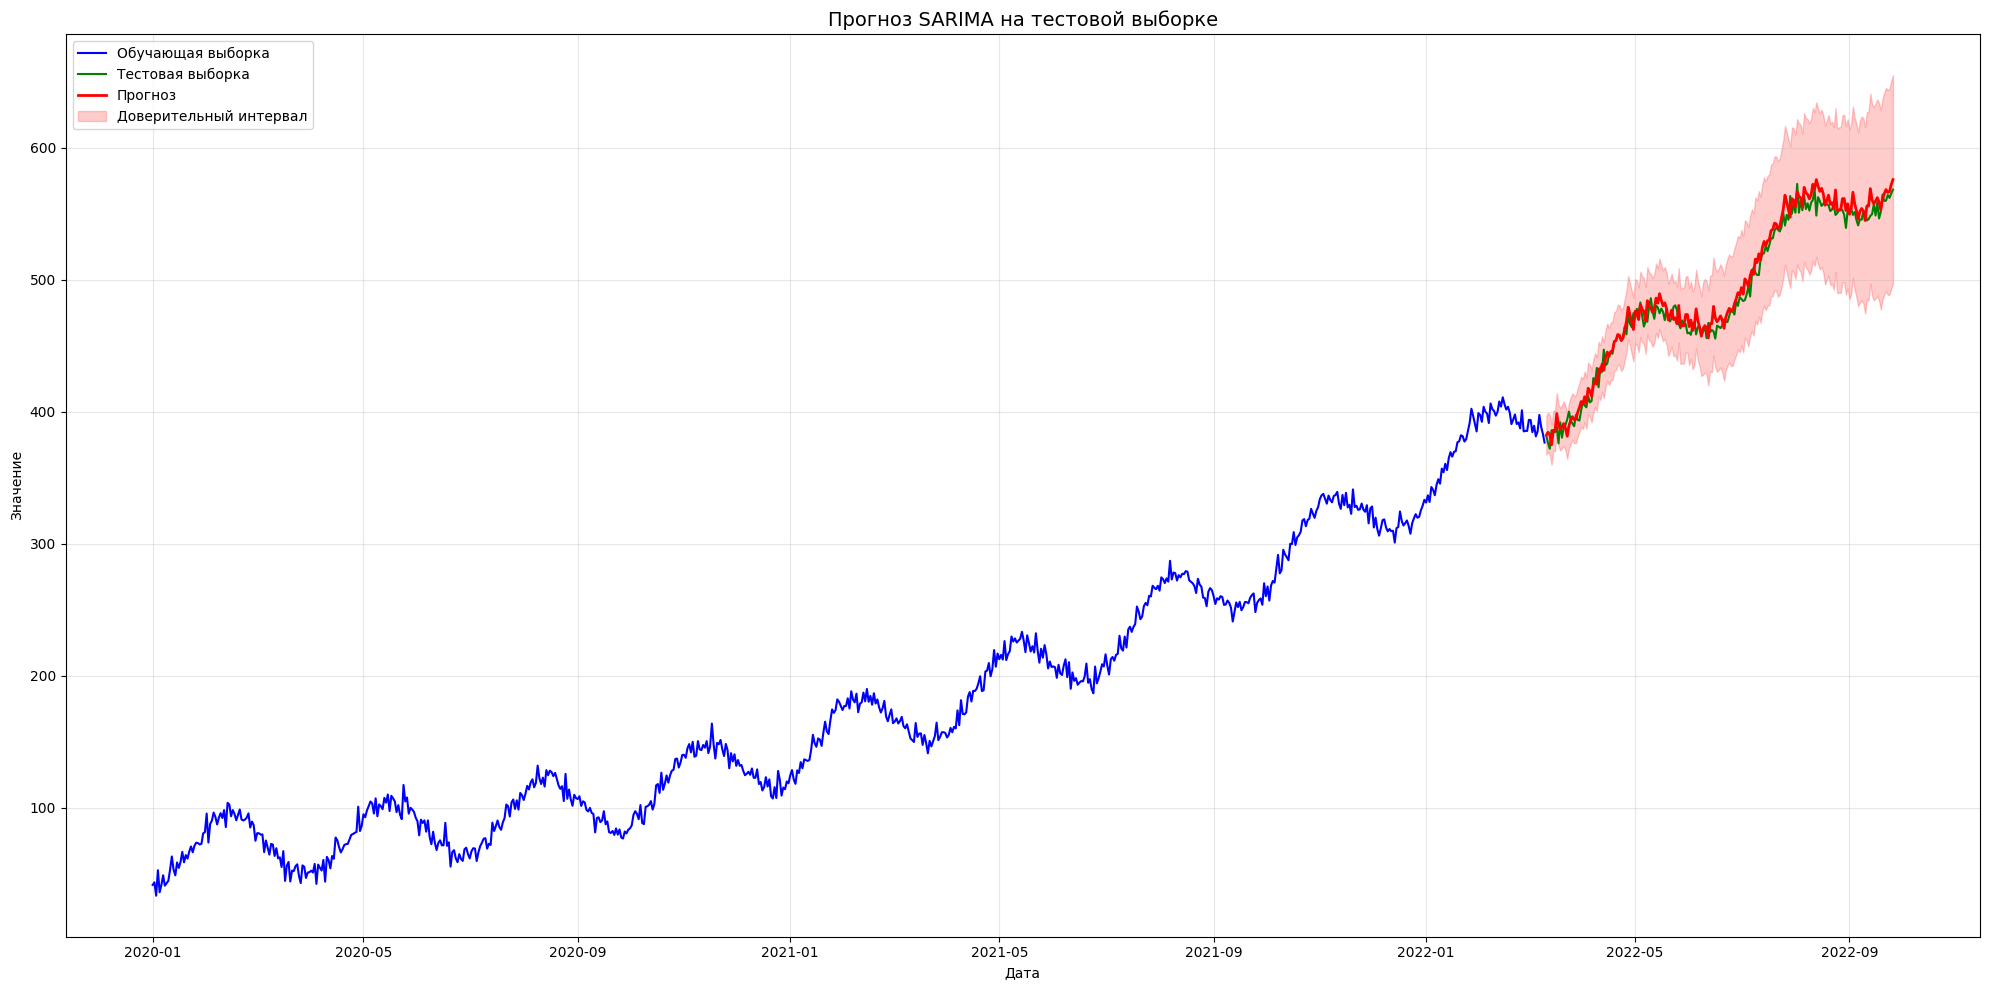

In [13]:
# Разделение на train/test
train_size = int(len(pd_values) * 0.8)
train = pd_values.iloc[:train_size]
test = pd_values.iloc[train_size:]

order = (9, 2, 1)  # (p, d, q)
seasonal_order = (0, 1, 0, 90)  # (P, D, Q, s)

# Обучение модели
model = SARIMAX(train, 
                order=order, 
                seasonal_order=seasonal_order)

model_fit = model.fit(disp=False, maxiter=200)
print(model_fit.summary())

# Прогноз на тестовой выборке 
forecast_steps = len(test)
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
forecast_conf_int = forecast_result.conf_int()

# Метрики качества на тестовой выборке
mae = mean_absolute_error(test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f"\nМетрики качества на тестовой выборке:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# Визуализация
plt.figure(figsize=(20, 10))

# Обучающая выборка
plt.plot(train.index, train, label='Обучающая выборка', color='blue')

# Тестовая выборка
plt.plot(test.index, test, label='Тестовая выборка', color='green')

# Прогноз
plt.plot(test.index, forecast, label='Прогноз', color='red', linewidth=2)

# Доверительный интервал
plt.fill_between(test.index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='Доверительный интервал')

plt.title('Прогноз SARIMA на тестовой выборке', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

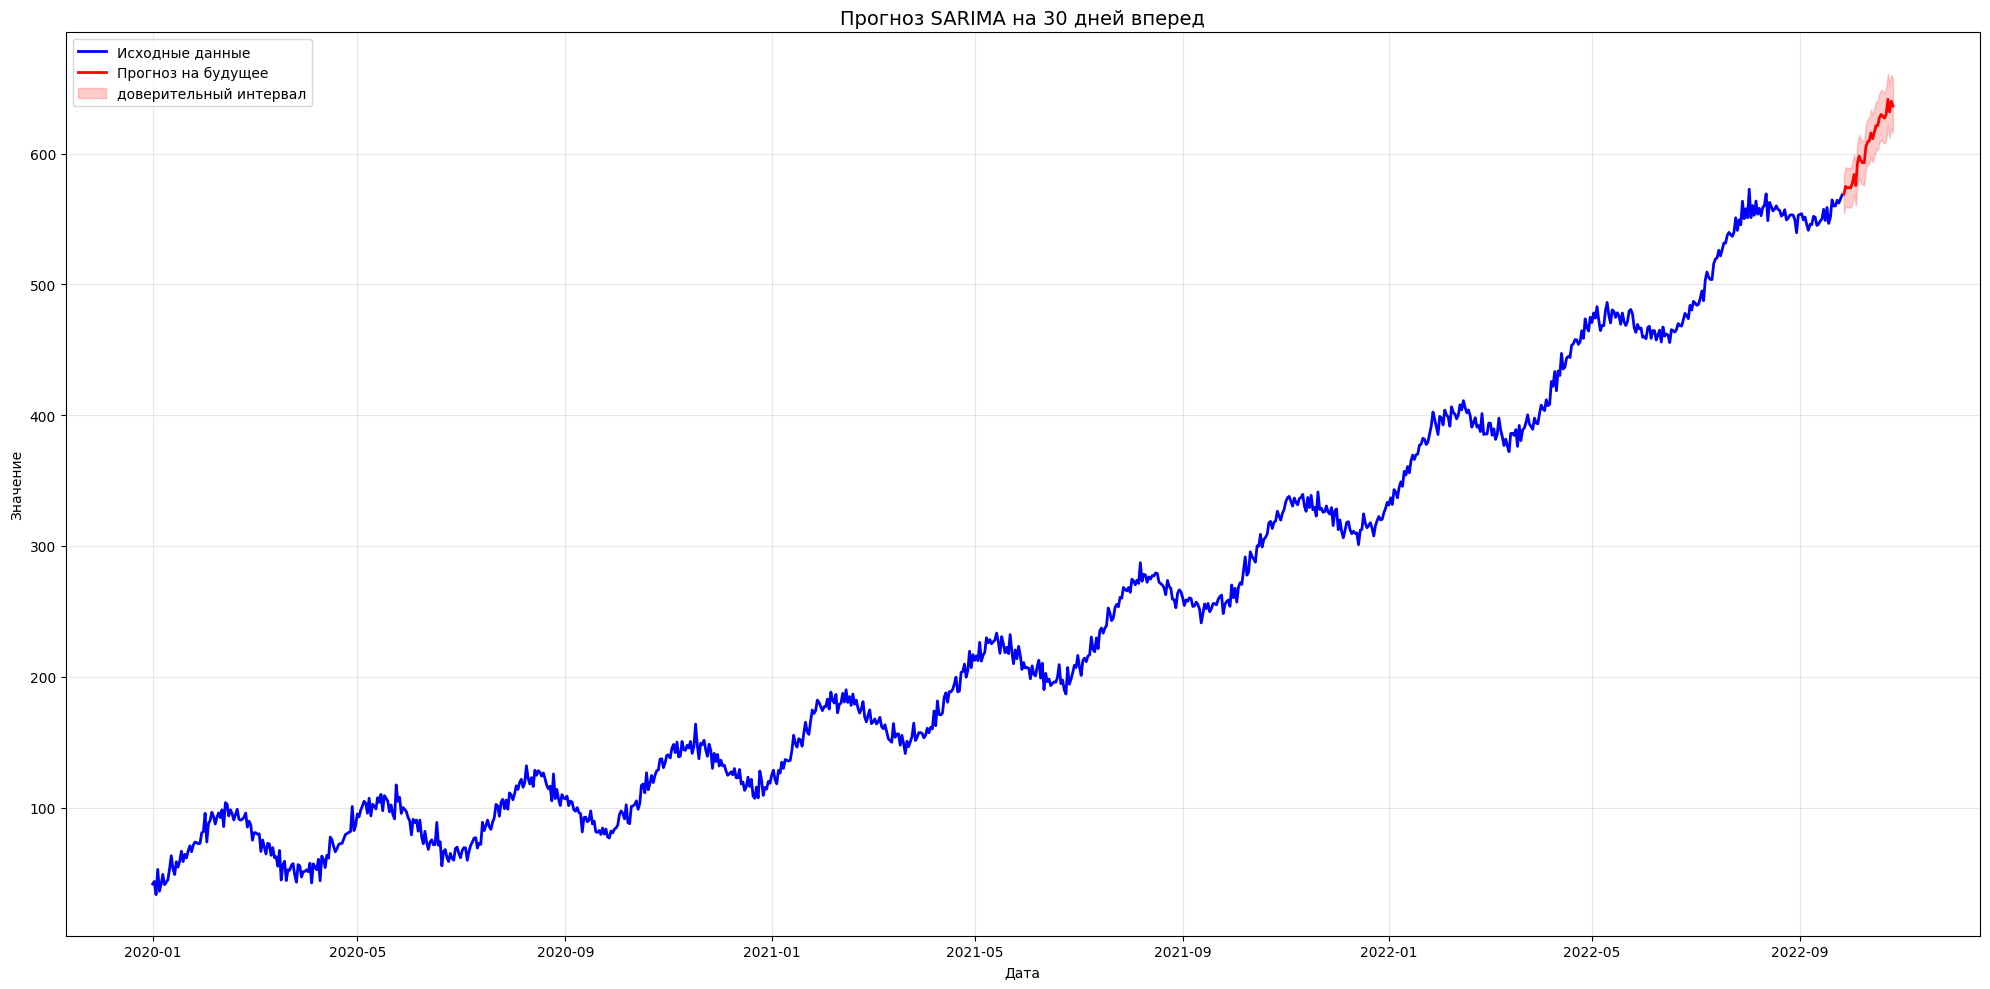

In [14]:
# Прогноз на будущее
future_steps = 30
update_model = model_fit.append(test, refit=False)
future_forecast_result = update_model.get_forecast(steps=future_steps)
future_forecast = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

# Создание дат для будущего прогноза
last_date = pd_values.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
                             periods=future_steps, 
                             freq='D')

# Визуализация полного прогноза
plt.figure(figsize=(20, 10))

# Все исходные данные
plt.plot(pd_values.index, pd_values, label='Исходные данные', color='blue', linewidth=2)

# Прогноз на будущее
plt.plot(future_dates, future_forecast, label='Прогноз на будущее', color='red', linewidth=2)

# Доверительный интервал
plt.fill_between(future_dates,
                 future_conf_int.iloc[:, 0],
                 future_conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='доверительный интервал')

plt.title(f'Прогноз SARIMA на {future_steps} дней вперед', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Лабораторная работа №2

Провести моделирование временного ряда из задачи 1 с помощью нейросетевых методов на свой выбор. Смоделировать ряд, сделав предсказание на разумный период. Провести анализ метрик. Изобразить график модели с предсказанием с учетом возможных ошибок. Сделать заключение, сравнив результаты

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0388 - mae: 0.1560 - val_loss: 0.0156 - val_mae: 0.1202
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0082 - mae: 0.0738 - val_loss: 0.0192 - val_mae: 0.1354
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0028 - mae: 0.0421 - val_loss: 0.0017 - val_mae: 0.0345
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0019 - mae: 0.0340 - val_loss: 0.0026 - val_mae: 0.0436
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013 - mae: 0.0289 - val_loss: 0.0022 - val_mae: 0.0365
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0012 - mae: 0.0275 - val_loss: 0.0025 - val_mae: 0.0395
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0010 - mae: 0.0255 - val_loss: 8.3579e-04 - val_mae: 0.0242
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0010 - mae: 0.0244 - val_loss: 9.0738e-04 - val_mae: 0.0247
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - los

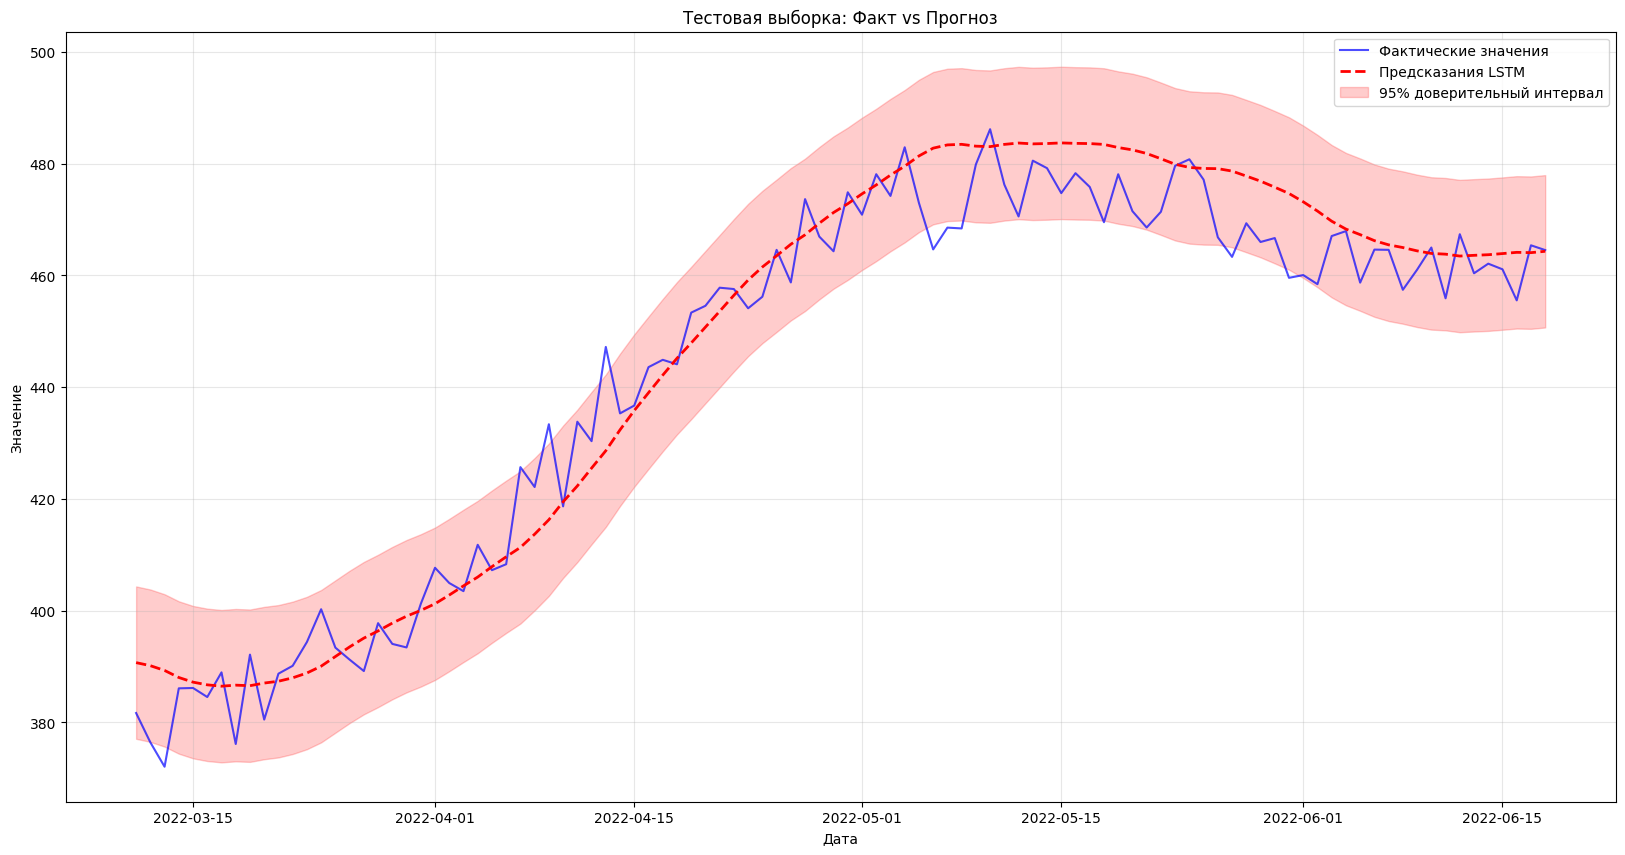

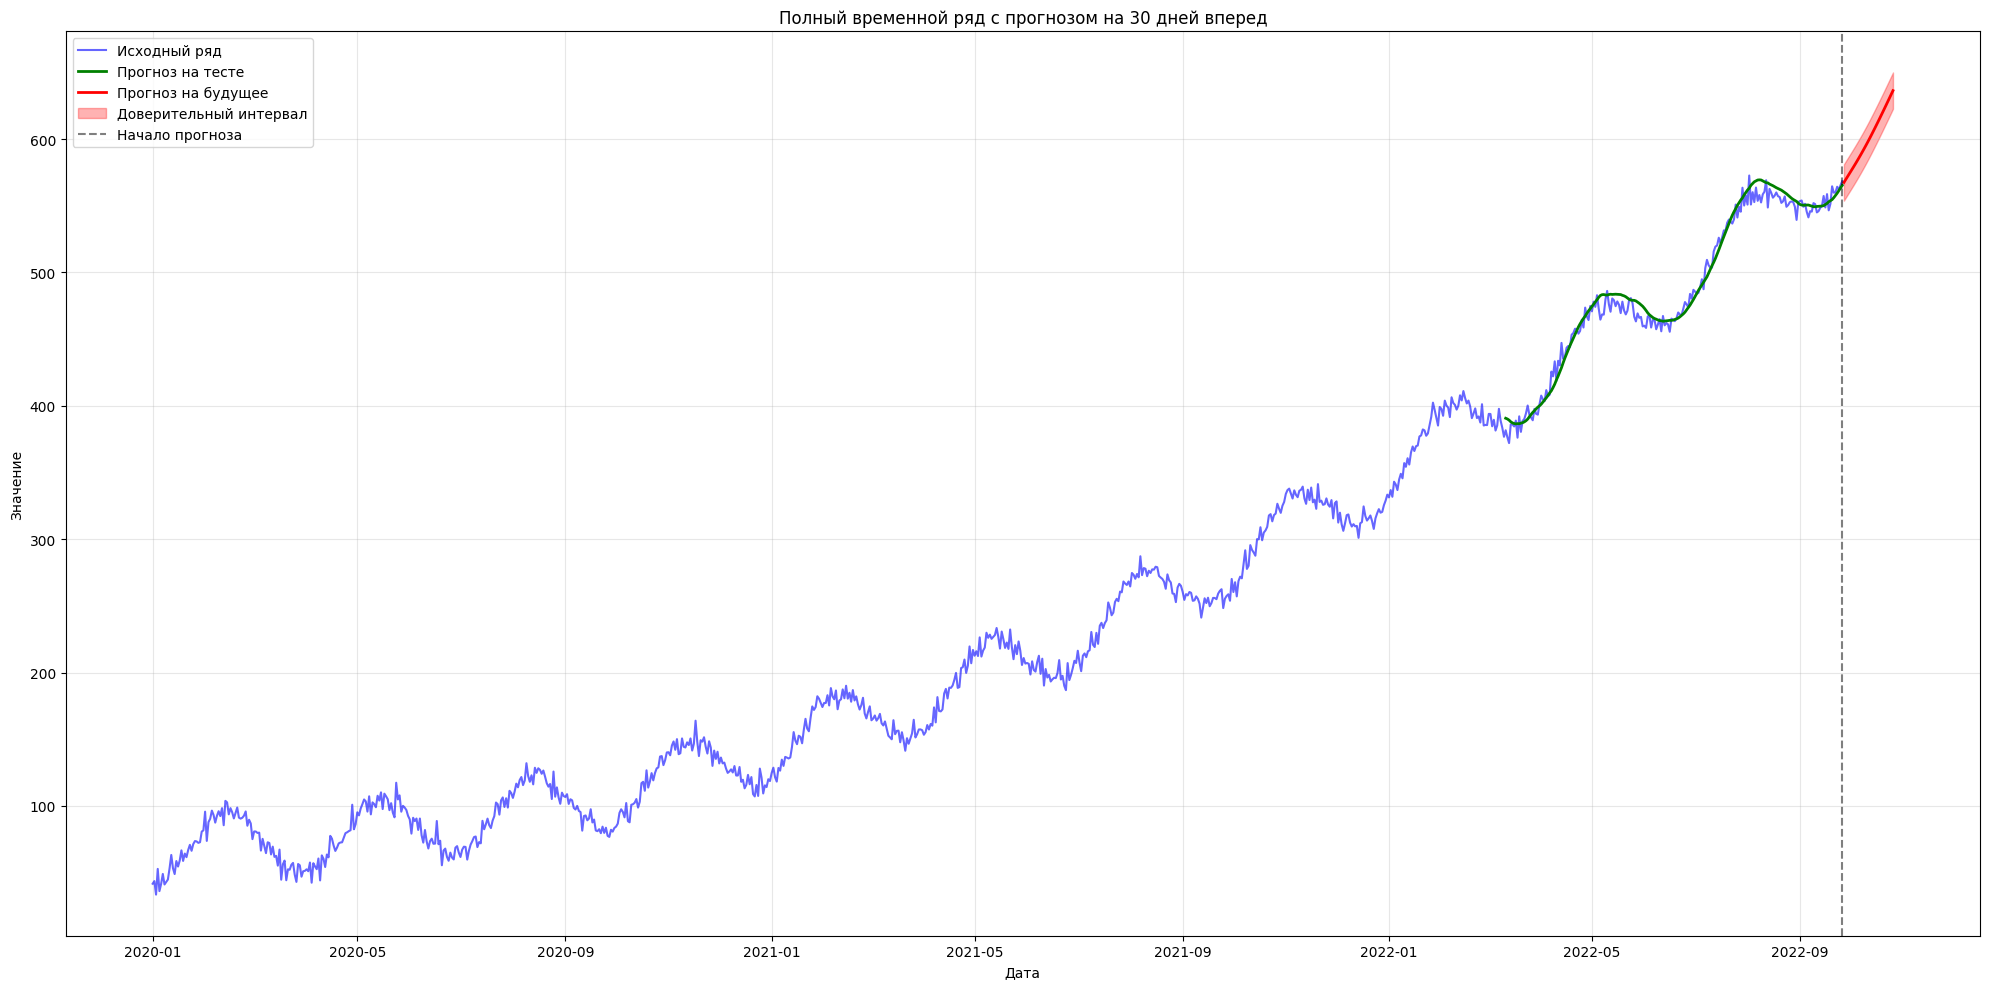

In [16]:
# Подготовка данных для LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values.reshape(-1, 1)).flatten()

# Параметры для обучения
SEQ_LENGTH = 60  # Используем 60 точек для предсказания следующей
TEST_SIZE = 200  # Последние 200 точек для теста
TRAIN_SIZE = len(values_scaled) - TEST_SIZE - SEQ_LENGTH
FORECAST_HORIZON = 30

# Создание последовательностей
X, y = create_sequences(values_scaled, SEQ_LENGTH)

# Разделение на train/test
X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE]
y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE]

# Изменение формы для LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Создание модели LSTM
model = keras.Sequential([
    layers.LSTM(100, activation='relu', return_sequences=True, 
                input_shape=(SEQ_LENGTH, 1)),
    layers.Dropout(0.2),
    layers.LSTM(50, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(25, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Обучение модели
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 4. Прогнозирование на тестовой выборке
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Прогнозирование на будущие периоды 
def forecast_future(model, last_sequence, horizon):
    """
    Прогнозирование на несколько шагов вперед
    
    last_sequence: последняя известная последовательность
    horizon: количество шагов для прогноза
    """
    future_predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(horizon):
        # Подготовка текущей последовательности
        current_input = current_sequence.reshape(1, SEQ_LENGTH, 1)
        
        # Прогноз на следующий шаг
        next_pred_scaled = model.predict(current_input, verbose=0)[0, 0]
        future_predictions.append(next_pred_scaled)
        
        # Обновление последовательности
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = next_pred_scaled
    
    return np.array(future_predictions)

# Последняя последовательность из тестовых данных
last_sequence = values_scaled[-SEQ_LENGTH:]

# Прогноз
future_scaled = forecast_future(model, last_sequence, FORECAST_HORIZON)
future_predictions = scaler.inverse_transform(future_scaled.reshape(-1, 1)).flatten()

# Даты для прогноза
last_date = date_objects[-1]
future_dates = [last_date + timedelta(days=i+1) for i in range(FORECAST_HORIZON)]

# Анализ метрик
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    }

metrics = calculate_metrics(y_test_original, y_pred)

print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ:")
print("="*50)
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# 7. Расчет доверительных интервалов
# Используем остатки для оценки неопределенности
residuals = y_test_original - y_pred
residual_std = np.std(residuals)

# Доверительные интервалы (95%)
confidence_interval = 1.96 * residual_std

# Для будущих прогнозов
future_upper = future_predictions + confidence_interval
future_lower = future_predictions - confidence_interval


plt.figure(figsize=(20, 10))

test_dates = date_objects[TRAIN_SIZE+SEQ_LENGTH:TRAIN_SIZE+SEQ_LENGTH+TEST_SIZE]
plt.plot(test_dates[:100], y_test_original[:100], 'b-', label='Фактические значения', alpha=0.7)
plt.plot(test_dates[:100], y_pred[:100], 'r--', label='Предсказания LSTM', linewidth=2)
plt.fill_between(test_dates[:100], 
                 y_pred[:100] - confidence_interval, 
                 y_pred[:100] + confidence_interval,
                 alpha=0.2, color='red', label='95% доверительный интервал')
plt.title('Тестовая выборка: Факт vs Прогноз')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)

plt.figure(figsize=(20, 10))
plt.plot(date_objects, values, 'b-', label='Исходный ряд', alpha=0.6)

test_start_idx = TRAIN_SIZE + SEQ_LENGTH
test_end_idx = test_start_idx + len(y_pred)
test_plot_dates = date_objects[test_start_idx:test_end_idx]
plt.plot(test_plot_dates, y_pred, 'g-', label='Прогноз на тесте', linewidth=2)

plt.plot(future_dates, future_predictions, 'r-', label='Прогноз на будущее', linewidth=2, markersize=4)
plt.fill_between(future_dates, future_lower, future_upper,
                 alpha=0.3, color='red', label='Доверительный интервал')

plt.axvline(x=date_objects[-1], color='k', linestyle='--', alpha=0.5, label='Начало прогноза')
plt.title('Полный временной ряд с прогнозом на 30 дней вперед')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Вывод
По результатам сравнения моделей SARIMA и LSTM выявил, что модель SARIMA обеспечивает более точный прогноз временного ряда. Значения ошибок MAE и RMSE у SARIMA ниже, чем у LSTM, а показатель MAPE (1.34%) свидетельствует о высокой относительной точности прогноза. Так же SARIMA дает более детальное предсказание, а LSTM показывает больше направление предсказания.